# Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

# Load Data

In [3]:
data = pd.read_csv('Data/final_transport_data.csv')
print(data.columns)

Index(['TRANSPORT', 'NO_STOPS', 'DISTANCE', 'PRICE', 'DISTRICT',
       'NEXT DISTRICT', 'STOP_COUNT', 'STOP_COUNT_UNIQUE', 'AREA', 'DENSITY',
       'DENSITY_UNIQUE', 'DENSITY*10000', 'DENSITY_UNIQUE*100000',
       'LIVING POPULATION', 'WORKING POPULATION', 'BUILDING NUMBER',
       'ESTIMATED EMPLOYED POPULATION', 'MEDIAN MONTHLY INCOME',
       'NEXT STOP_COUNT', 'NEXT STOP_COUNT_UNIQUE', 'NEXT AREA',
       'NEXT DENSITY', 'NEXT DENSITY_UNIQUE', 'NEXT DENSITY*10000',
       'NEXT DENSITY_UNIQUE*100000', 'NEXT LIVING POPULATION',
       'NEXT WORKING POPULATION', 'NEXT BUILDING NUMBER',
       'NEXT ESTIMATED EMPLOYED POPULATION', 'NEXT MEDIAN MONTHLY INCOME',
       'PASS HARBOUR'],
      dtype='object')


In [5]:
data['PRICE'].describe()

count    1.352034e+06
mean     2.001796e+01
std      9.013345e+00
min      3.800000e+00
25%      1.170000e+01
50%      2.100000e+01
75%      2.720000e+01
max      3.740000e+01
Name: PRICE, dtype: float64

/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/2482315638.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


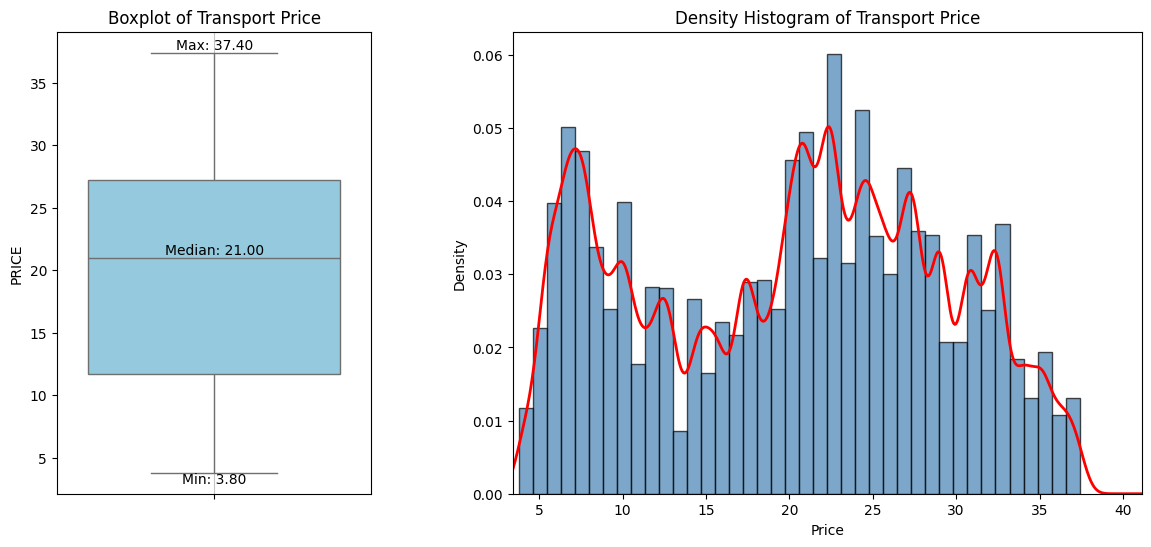

In [ ]:
# Combined boxplot and histogram for PRICE (side by side with adjusted widths and value labels)
plt.figure(figsize=(14, 6))

# Create a gridspec layout with 2 columns, allocating 1/3 width to the boxplot and 2/3 to the histogram
grid = plt.GridSpec(1, 2, width_ratios=[1, 2], wspace=0.3)

# Boxplot (left, smaller width)
plt.subplot(grid[0])
boxplot = sns.boxplot(y='PRICE', data=data, orient='v', color='skyblue')
plt.title('Boxplot of Transport Price', fontsize=12)
plt.grid(axis='x', alpha=0.75)

# Add median, max, and min value labels
stats = data['PRICE'].describe()
median = stats['50%']
min_val = stats['min']
max_val = stats['max']

# Annotate the boxplot
plt.text(0, median, f'Median: {median:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.text(0, min_val, f'Min: {min_val:.2f}', ha='center', va='top', fontsize=10, color='black')
plt.text(0, max_val, f'Max: {max_val:.2f}', ha='center', va='bottom', fontsize=10, color='black')

# Histogram (right, larger width)
plt.subplot(grid[1])
plt.hist(data['PRICE'], bins=40, alpha=0.7, density=True, color='steelblue', edgecolor='black')
plt.title('Density Histogram of Transport Price', fontsize=12)
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)

# Add KDE line to the histogram
data['PRICE'].plot(kind='kde', color='red', linewidth=2, ax=plt.gca())

# Adjust x-axis limits
min_price = data['PRICE'].min()
max_price = data['PRICE'].max()
plt.xlim(min_price * 0.9, max_price * 1.1)

plt.tight_layout()
plt.show()

In [84]:
areas_to_districts = {
    "Kwai Tsing": ["Tsing Yi", "Kwai Chung East", "Kwai Chung West"],
    "North": ["Wu Tip Shan", "Robin's Nest"],
    "Sai Kung": ["Sai Kung and Hang Hau", "Tseung Kwan O South", "Tseung Kwan O North", "Hang Hau"],
    "Sha Tin": ['Sha Tin West', 'Sha Tin East', 'Sha Tin South', 'Sha Tin North'],
    "Tai Po": ['Tai Po South', 'Tai Po North'],
    "Tsuen Wan": ['Tsuen Wan Northwest', 'Tsuen Wan Southeast'],
    "Tuen Mun": ['Tuen Mun East', 'Tuen Mun West', 'Tuen Mun North'],
    "Yuen Long": ['Yuen Long Town Centre', 'Yuen Long Rural East', 'Tin Shui Wai South and Ping Ha'],
    "Kowloon City": ['Kowloon City North', 'Kowloon City South'],
    "Kwun Tong": ['Kwun Tong Southeast', 'Kwun Tong Central', 'Kwun Tong North', 'Kwun Tong West'],
    "Sham Shui Po": ['Sham Shui Po West', 'Sham Shui Po East'],
    "Wong Tai Sin": ['Wong Tai Sin East', 'Wong Tai Sin West'],
    "Yau Tsim Mong": ['Yau Tsim Mong South', 'Yau Tsim Mong North'],
    "Central and Western": ['Central', 'Western'],
    "Eastern": ['Tai Pak', 'Hong Wan', 'Chai Wan'],
    "Southern": ['Southern District Southeast', 'Southern District Northwest'],
    "Wan Chai": ['Wan Chai'],
    "Islands": ['Islands']
}

district_to_area = {}
for area, districts in areas_to_districts.items():
    for district in districts:
        district_to_area[district] = area

data['Origin District'] = data['DISTRICT'].map(district_to_area)   
data['Destination District'] = data['NEXT DISTRICT'].map(district_to_area)   

hong_kong = ["Central and Western", "Eastern", "Southern", "Wan Chai"]
kowloon = ["Yau Tsim Mong", "Sham Shui Po", "Kowloon City", "Wong Tai Sin", "Kwun Tong"]
new_territories = ["Kwai Tsing", "Tsuen Wan", "Tuen Mun", "Yuen Long", "North", "Tai Po", "Sha Tin", "Sai Kung", "Islands"]

df_hong_kong = data[data['Origin District'].isin(hong_kong)]
df_kowloon = data[data['Origin District'].isin(kowloon)]
df_new_territories = data[data['Origin District'].isin(new_territories)]

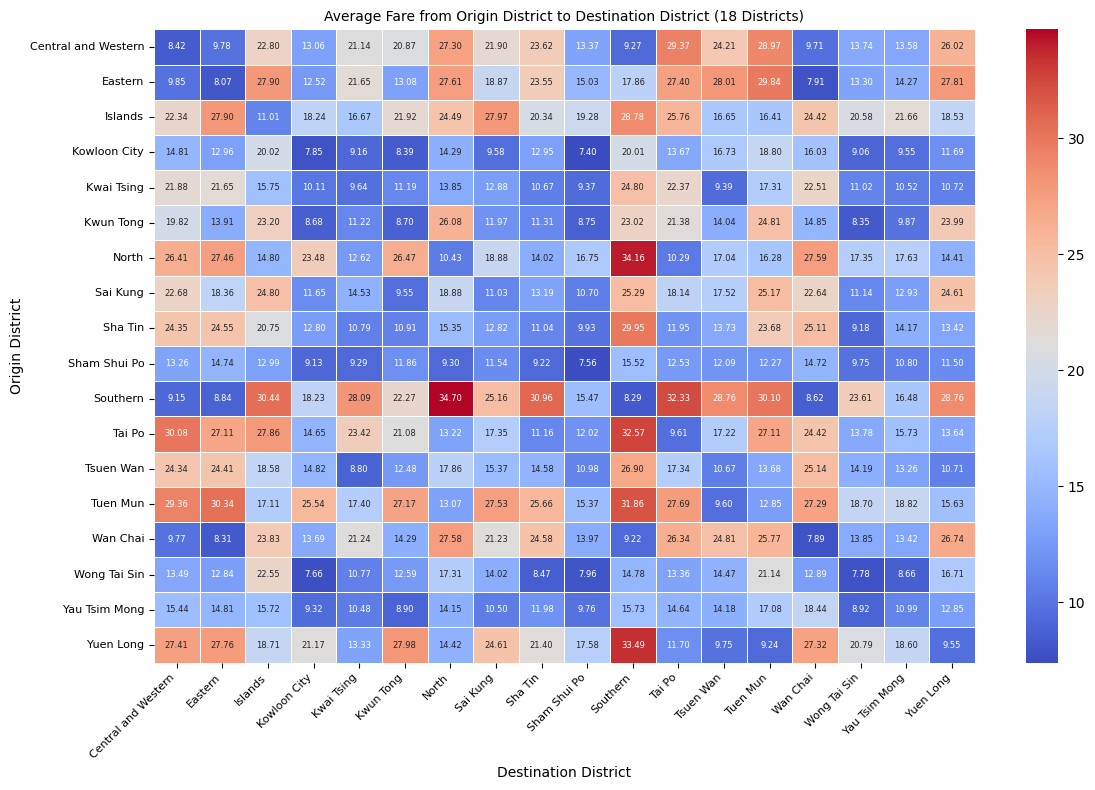

In [88]:
# Calculate the average fare between origin and destination districts
avg_fare_matrix = data.pivot_table(index='Destination District', columns='Origin District', values='PRICE', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(12, 8))
sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 6})
plt.title('Average Fare from Origin District to Destination District (18 Districts)', fontsize=10)
plt.xlabel('Destination District', fontsize=10)
plt.ylabel('Origin District', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

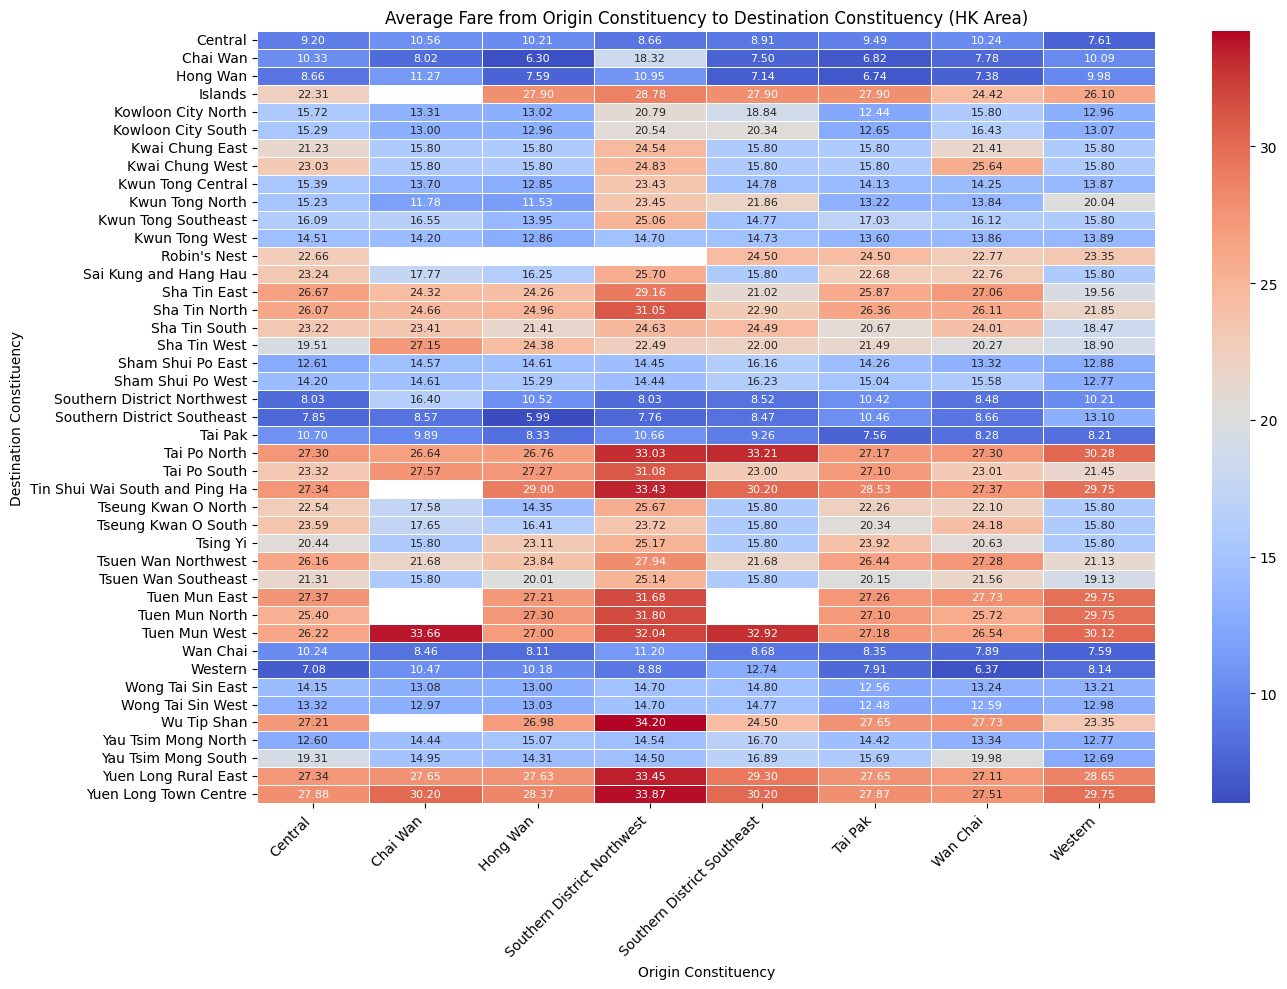

In [9]:
avg_fare_matrix = df_hong_kong.pivot_table(index='NEXT DISTRICT', columns='DISTRICT', values='PRICE', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency (HK Area)')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

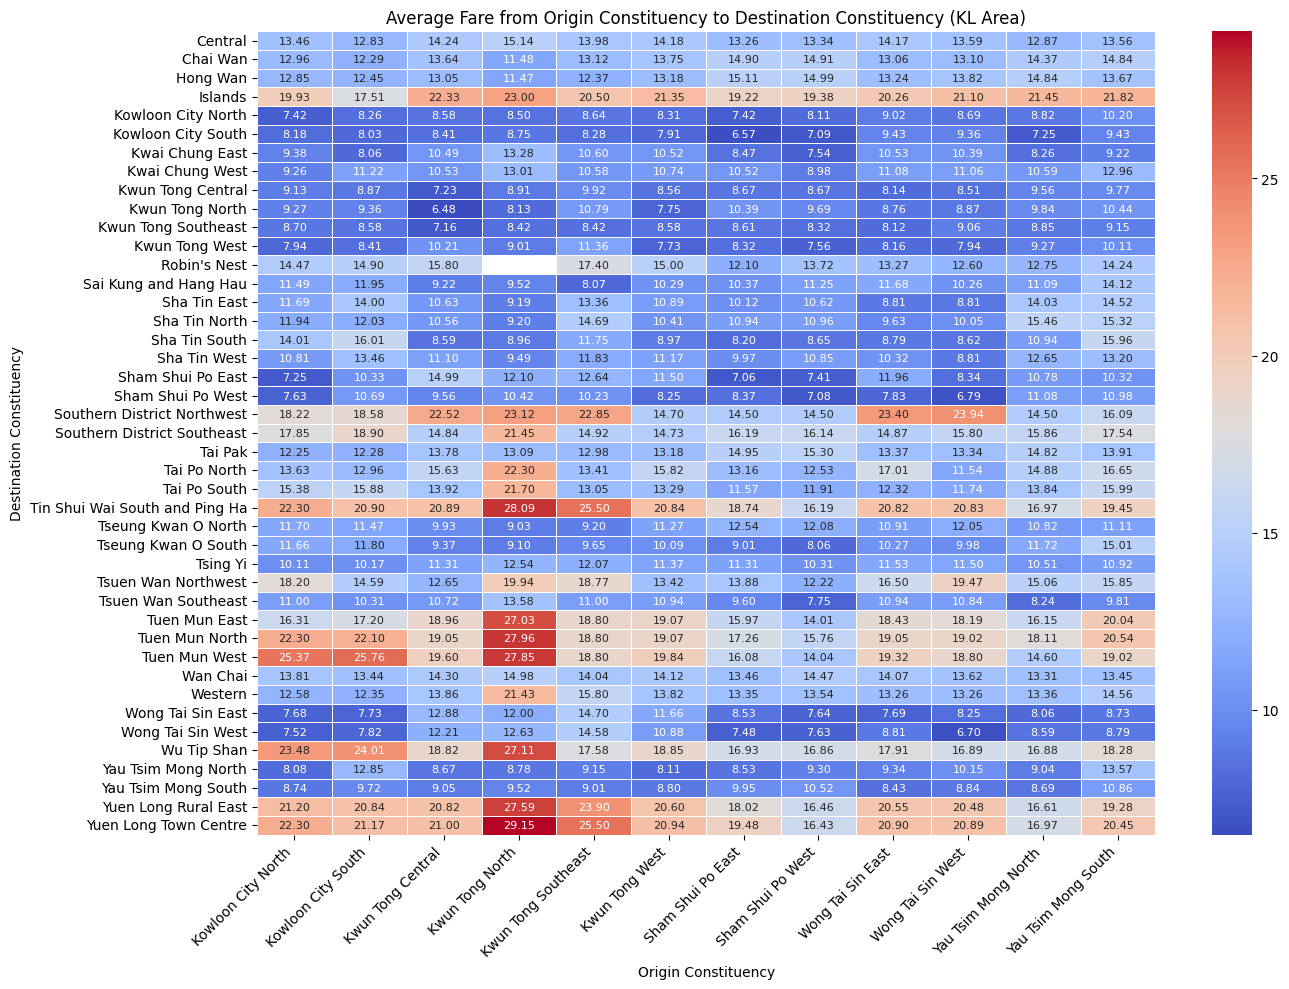

In [10]:
avg_fare_matrix = df_kowloon.pivot_table(index='NEXT DISTRICT', columns='DISTRICT', values='PRICE', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency (KL Area)')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

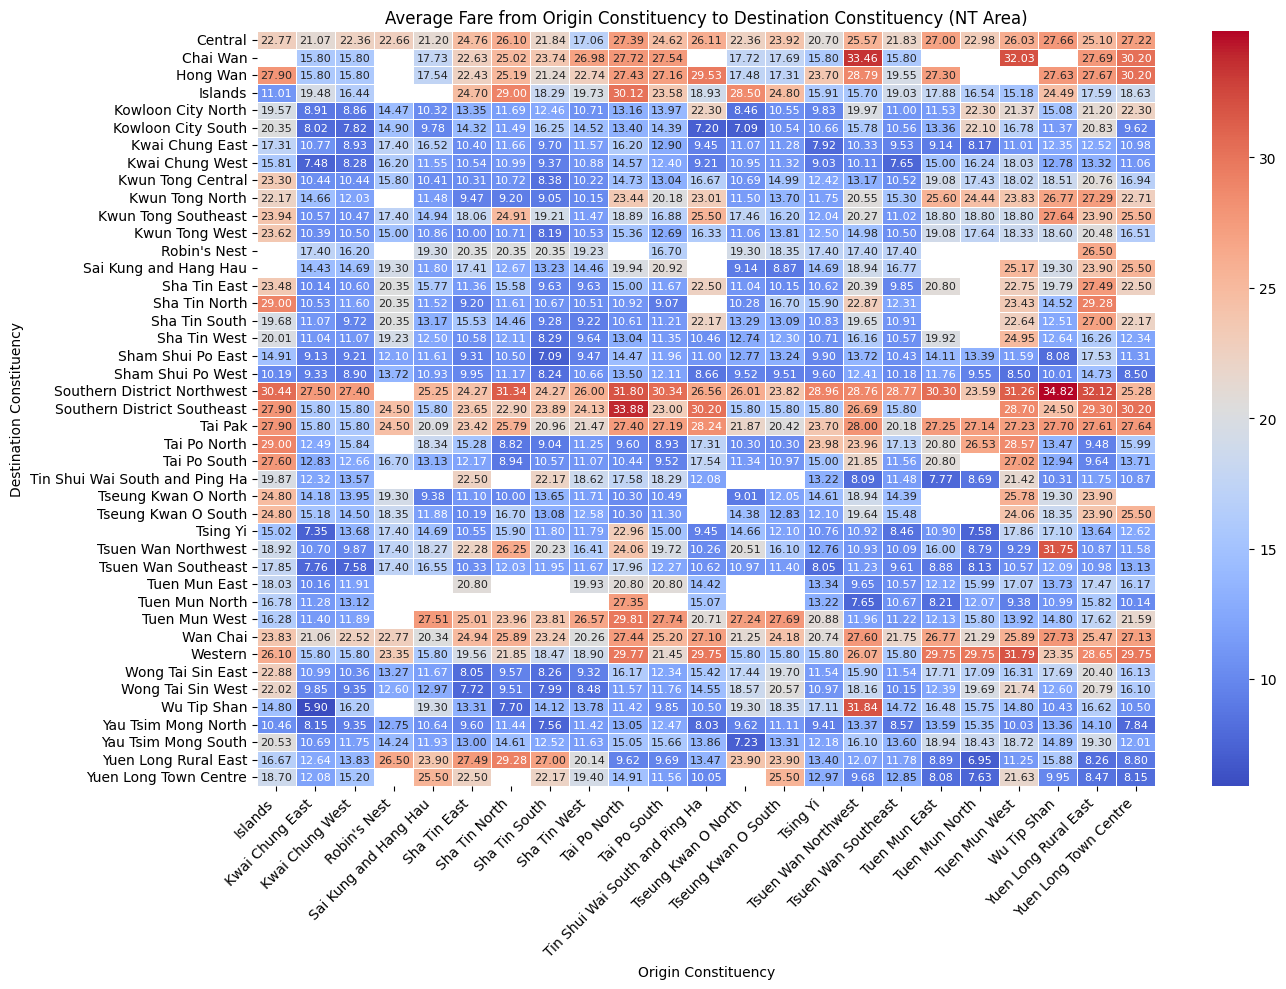

In [11]:
avg_fare_matrix = df_new_territories.pivot_table(index='NEXT DISTRICT', columns='DISTRICT', values='PRICE', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency (NT Area)')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/1058435142.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=constituency_avg_price.index,


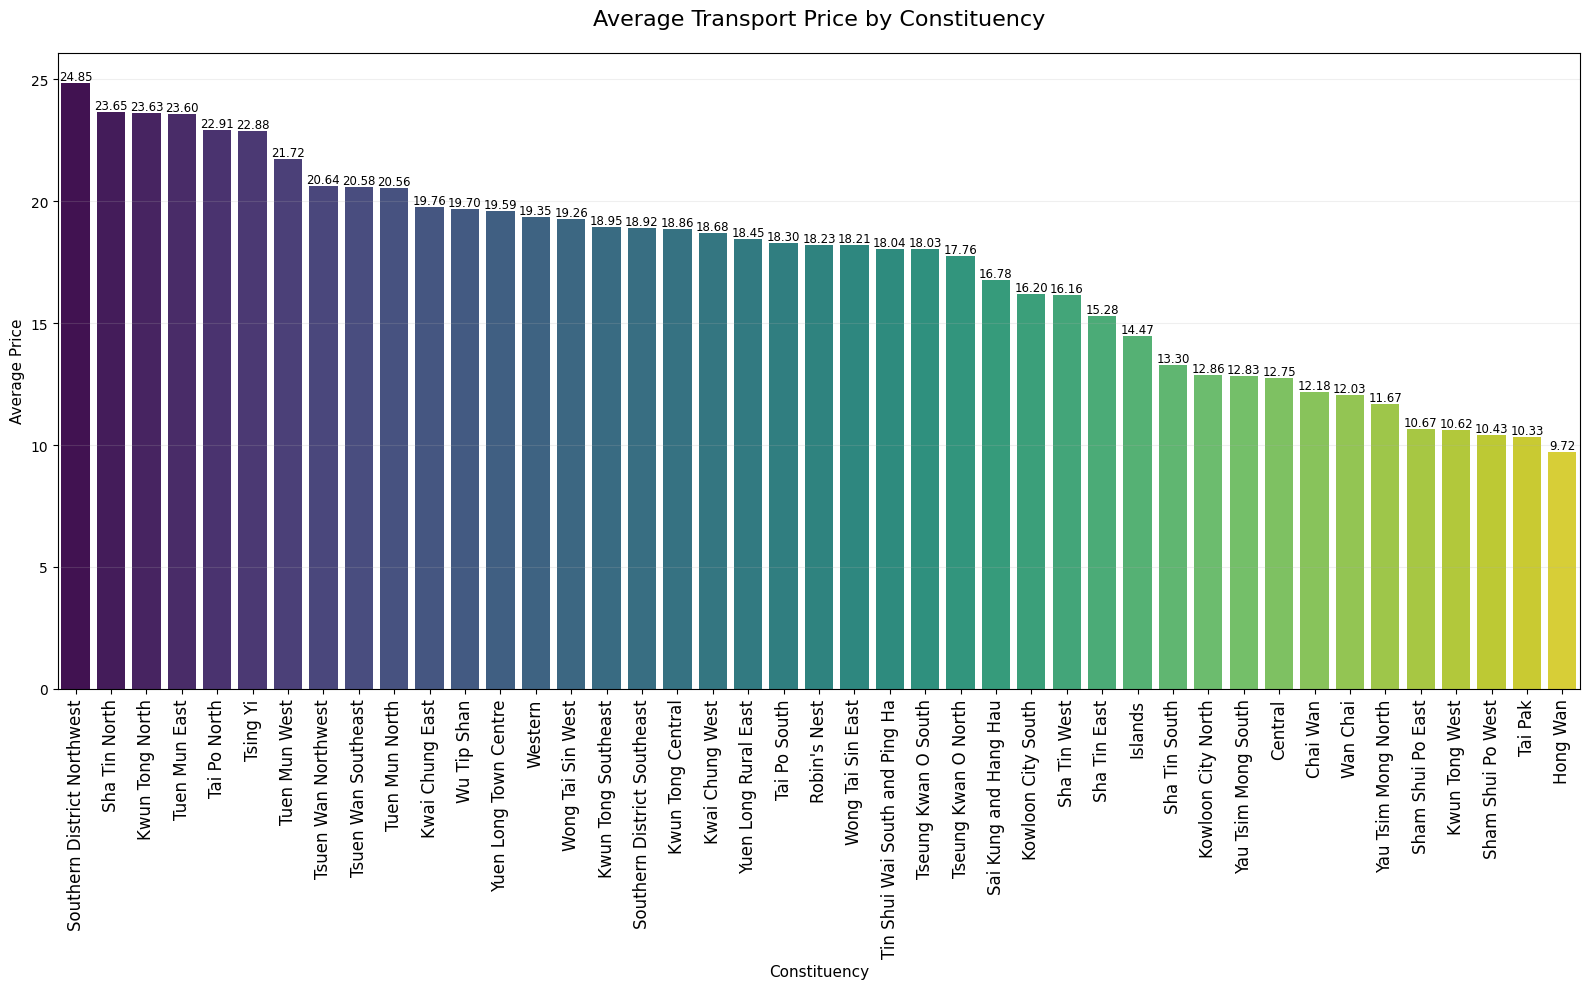

In [79]:
constituency_avg_price = data.groupby('DISTRICT')['PRICE'].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 10))
ax = sns.barplot(x=constituency_avg_price.index, 
                 y=constituency_avg_price.values,
                 palette='viridis')

# Add value labels
for i, price in enumerate(constituency_avg_price.values):
    ax.text(i, price, f'{price:.2f}', 
            ha='center', va='bottom', rotation=0, fontsize=8.5)

plt.title('Average Transport Price by Constituency', 
          fontsize=16, pad=20)
plt.xlabel('Constituency', fontsize=11)
plt.ylabel('Average Price', fontsize=11)
plt.xticks(rotation=90, fontsize=12)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/319786240.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = data.groupby('DISTANCE_BIN')['PRICE'].mean().reset_index()


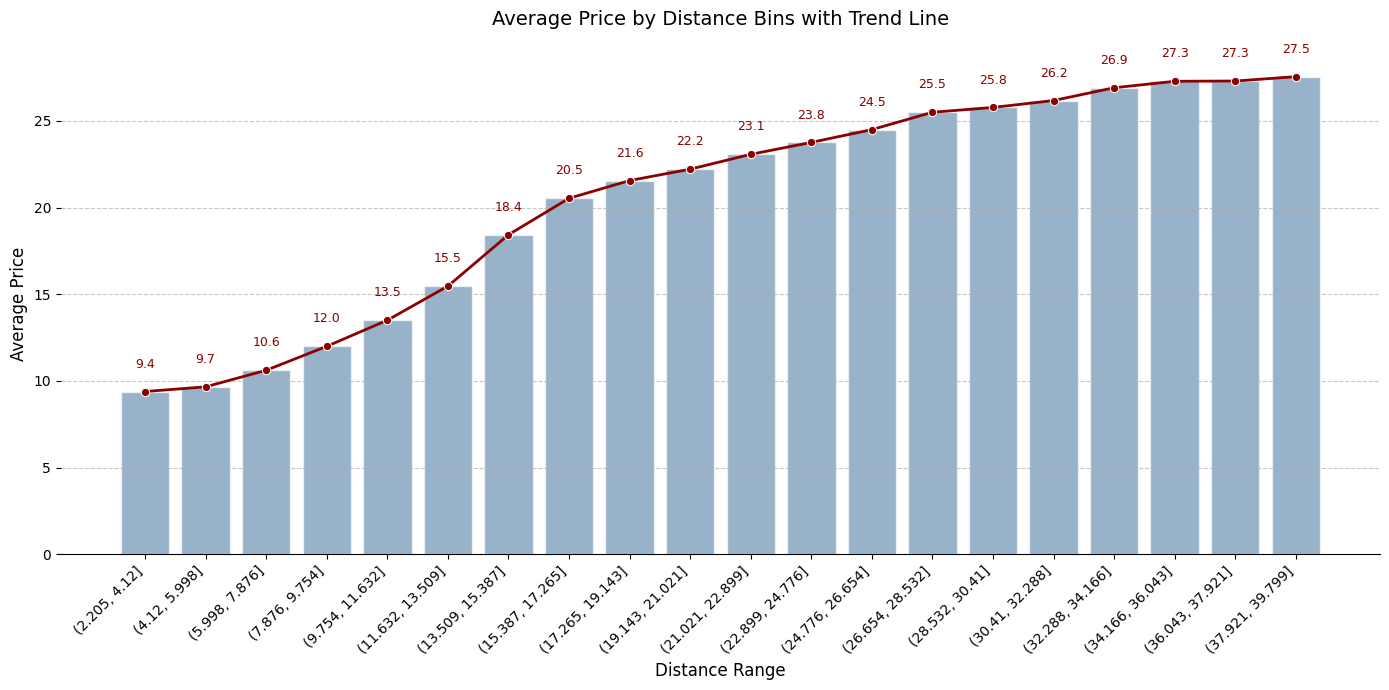

In [72]:
data['DISTANCE_BIN'] = pd.cut(data['DISTANCE'], bins=20)
agg_df = data.groupby('DISTANCE_BIN')['PRICE'].mean().reset_index()

plt.figure(figsize=(14, 7))

# Create bar plot
ax = sns.barplot(x='DISTANCE_BIN', y='PRICE', data=agg_df, 
                 edgecolor='white', alpha=0.6, color='#4682B4')

# Create line plot on same axis
line = sns.lineplot(x=np.arange(len(agg_df)), y='PRICE', data=agg_df, 
                    marker='o', color='darkred', linewidth=2, ax=ax)

# Customize the plot
plt.title('Average Price by Distance Bins with Trend Line', fontsize=14, pad=20)
ax.set_xlabel('Distance Range', fontsize=12)
ax.set_ylabel('Average Price', fontsize=12)

# Rotate x-axis labels and adjust alignment
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add value labels on top of bars
# for p in ax.patches:
#     ax.annotate(f"{p.get_height():.1f}", 
#                 (p.get_x() + p.get_width() / 2., p.get_height()), 
#                 ha='center', va='center', 
#                 xytext=(0, 5), 
#                 textcoords='offset points',
#                 fontsize=9)

# Add value labels for line points
for index, row in agg_df.iterrows():
    ax.text(x=index, 
           y=row['PRICE'] + (0.05 * agg_df['PRICE'].max()),
           s=f"{row['PRICE']:.1f}", 
           ha='center',
           color='darkred',
           fontsize=9)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Remove spines
sns.despine(left=True)

plt.tight_layout()
plt.show()

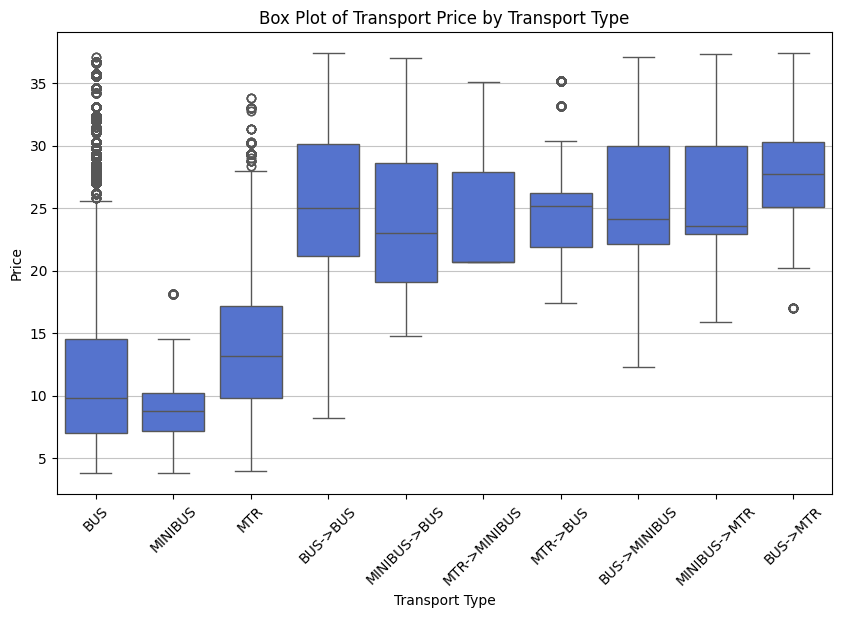

In [82]:
# pair box plot of price and 'TRANSPORT'
plt.figure(figsize=(10, 6))
sns.boxplot(x='TRANSPORT', y='PRICE', data=data, color='royalblue')
plt.title('Box Plot of Transport Price by Transport Type')
plt.xlabel('Transport Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()


/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/2573108057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='PASS HARBOUR', y='PRICE', data=data, palette=['#2ecc71', '#e74c3c'])


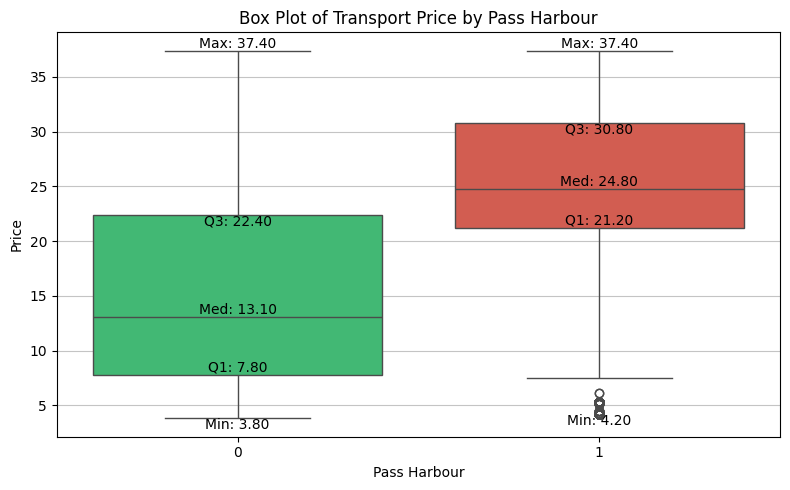

In [91]:
# pair box plot of price and 'PASS HARBOUR'
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='PASS HARBOUR', y='PRICE', data=data, palette=['#2ecc71', '#e74c3c'])

# Calculate statistics for each category
stats = data.groupby('PASS HARBOUR')['PRICE'].describe()

# Annotate each box with the statistics
for i, harbour in enumerate(stats.index):
    # Get values for this category
    q1 = stats.loc[harbour, '25%']
    q3 = stats.loc[harbour, '75%']
    median = stats.loc[harbour, '50%']
    whisker_min = stats.loc[harbour, 'min']
    whisker_max = stats.loc[harbour, 'max']
    
    # Position of the box
    x = i
    
    # Add text annotations
    ax.text(x, whisker_min, f'Min: {whisker_min:.2f}', ha='center', va='top', fontsize=10)
    ax.text(x, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(x, median, f'Med: {median:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(x, q3, f'Q3: {q3:.2f}', ha='center', va='top', fontsize=10)
    ax.text(x, whisker_max, f'Max: {whisker_max:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Box Plot of Transport Price by Pass Harbour')
plt.xlabel('Pass Harbour')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()  # Adjust layout to prevent text overlap
plt.show()

Districts with Low Income Group (24k-30k): ['Kwun Tong' 'Kwai Tsing' 'Tuen Mun' 'Wong Tai Sin' 'North' 'Sham Shui Po'] 

Districts with Medium Income Group (30k-35k): ['Yuen Long' 'Yau Tsim Mong' 'Tai Po' 'Kowloon City' 'Tsuen Wan' 'Eastern'
 'Sha Tin' 'Islands'] 

Districts with High Income Group (35k-42.6k): ['Sai Kung' 'Southern' 'Wan Chai' 'Central and Western'] 

INCOME_GROUP
High (35k-42.6k)    524751
Low (24k-30k)       453747
Medium (30k-35k)    373536
Name: count, dtype: int64


/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/3048106928.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='INCOME_GROUP', y='PRICE', data=data, order=income_labels, palette='Set2')
/var/folders/sg/hvr4hv7d1h56w4dn3njqrxh40000gn/T/ipykernel_13846/3048106928.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = data.groupby('INCOME_GROUP')['PRICE'].describe()


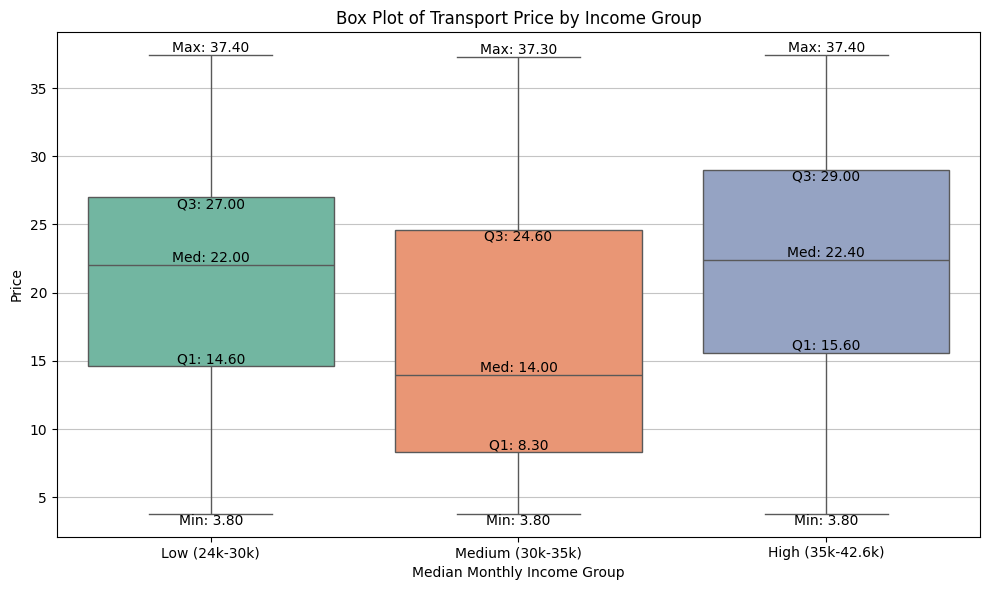

In [92]:
# Define income bins and labels
income_bins = [24000, 30000, 35000, 42600]  # Adjust based on your data distribution
income_labels = ['Low (24k-30k)', 'Medium (30k-35k)', 'High (35k-42.6k)']

# Create a new column for income groups
data['INCOME_GROUP'] = pd.cut(
    data['MEDIAN MONTHLY INCOME'], 
    bins=income_bins, 
    labels=income_labels,
    include_lowest=True
)

# print unique district name where income group is low 
low_income_districts = data[data['INCOME_GROUP'] == 'Low (24k-30k)']['Origin District'].unique()
print("Districts with Low Income Group (24k-30k):", low_income_districts, '\n')
medium_income_districts = data[data['INCOME_GROUP'] == 'Medium (30k-35k)']['Origin District'].unique()
print("Districts with Medium Income Group (30k-35k):", medium_income_districts, '\n')
high_income_districts = data[data['INCOME_GROUP'] == 'High (35k-42.6k)']['Origin District'].unique()
print("Districts with High Income Group (35k-42.6k):", high_income_districts, '\n')  

# Check group counts
print(data['INCOME_GROUP'].value_counts())

# pair box plot of price and 'income group'
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='INCOME_GROUP', y='PRICE', data=data, order=income_labels, palette='Set2')

# Calculate statistics for each category
stats = data.groupby('INCOME_GROUP')['PRICE'].describe()

# Annotate each box with the statistics
for i, harbour in enumerate(stats.index):
    # Get values for this category
    q1 = stats.loc[harbour, '25%']
    q3 = stats.loc[harbour, '75%']
    median = stats.loc[harbour, '50%']
    whisker_min = stats.loc[harbour, 'min']
    whisker_max = stats.loc[harbour, 'max']
    
    # Position of the box
    x = i
    
    # Add text annotations
    ax.text(x, whisker_min, f'Min: {whisker_min:.2f}', ha='center', va='top', fontsize=10)
    ax.text(x, q1, f'Q1: {q1:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(x, median, f'Med: {median:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(x, q3, f'Q3: {q3:.2f}', ha='center', va='top', fontsize=10)
    ax.text(x, whisker_max, f'Max: {whisker_max:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Box Plot of Transport Price by Income Group')
plt.xlabel('Median Monthly Income Group')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()  # Adjust layout to prevent text overlap
plt.show()